# AAV9 — GT score study with a Poisson-GLM regression GT

Same study as `AAV9_potts_GT_score_study.ipynb`, with the GT-construction method swapped:
instead of the joint ridge (Gaussian-on-log-enrichment) Potts regression from
`AAV9_potts_regression.ipynb`, this notebook fits `F`/`J` with a **Tweedie GLM, log link**,
directly on the **fold-enrichment ratio** `exp(target)` — `power=1` is the Poisson deviance
loss (`E[ratio] = exp(F.s + J.s.s + bias)`, `Var ∝ mean`).

**Why the ridge fit already is a (Gaussian) MLE, and what "a Poisson one" changes** — see
`docs/GT_MLE_vs_pseudolikelihood.pdf`. In short: ridge assumes `log(ratio) = score + N(0,σ²)`;
this notebook assumes `ratio ~ Poisson(exp(score))`.

**Structural caveat for the Poisson fit (`RegressionV1.fit_weights_glm_from_data` docstring).**
The Poisson objective is scale-equivariant: multiplying every `exp(target)` by a constant
multiplies the whole deviance by that constant and leaves `argmin F/J` unchanged. With only a
log-enrichment column — no real per-sequence before/after read counts to set a Poisson offset
— the fit is entirely determined by the *shape* of the ratio distribution, and its loss is
dominated by the handful of most-enriched sequences (largest ratio → largest fitted mean →
largest IRLS weight). A genuinely count-aware Poisson GT needs raw plasmid/vector counts
(`aav2.csv`/`aav5.csv` have them; `aav9.csv` does not).

For reference, the notebook also fits the **Gamma GLM** (`power=2`, constant coefficient of
variation) — the Tweedie family member actually matched to a positive ratio with wide dynamic
range — and carries the ridge Potts GT through every comparison as the incumbent.

## 0. Setup

In [1]:
import sys, os

# Locate Modelization_V2/lib by walking up from the cwd (= this notebook's dir), same robust
# idiom as test_for_sweep.ipynb / AAV9_cross_packaging_parameter_sweeps.ipynb: a hardcoded
# "../../lib" points nowhere from this subfolder and `import sequence_classesV1` then silently
# resolves to Modelization_V1's pip-installed copy.
_d = os.path.abspath("")
while os.path.basename(_d) != "Modelization_V2" and _d != os.path.dirname(_d):
    _d = os.path.dirname(_d)
_V2_LIB = os.path.join(_d, "lib")
assert os.path.isdir(_V2_LIB), f"Modelization_V2/lib not found walking up from {os.path.abspath('')}"
sys.path.insert(0, _V2_LIB)
sys.path.insert(0, os.path.abspath("."))
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"  # must be set before jax initializes

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

import RegressionV1 as R
from analysisV1 import AA_LABELS, pearson, precision_at_k, plot_cv_curve, plot_teacher_vs_student
from sequence_classesV1 import ProtocolV3
from initialize_weights import (
    load_F_viab_aav9_potts, load_J_viab_aav9_potts, NUM_AMINO_ACIDS, NUM_POSITIONS,
)

import sequence_classesV1 as _scv1, RegressionV1 as _r
assert "Modelization_V2" in _scv1.__file__, f"wrong sequence_classesV1: {_scv1.__file__}"
assert "Modelization_V2" in _r.__file__, f"wrong RegressionV1: {_r.__file__}"

print(f"JAX backend: {jax.default_backend()} -- devices: {jax.devices()}")
message = "AAV9 Poisson-GLM GT score study 1.0"

/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


JAX backend: gpu -- devices: [CudaDevice(id=0)]


## 1. Real AAV9 data

In [2]:
df = pd.read_csv("aav9.csv")
print(f"{len(df):,} variants, columns: {list(df.columns)}")

lengths = df["sequence"].str.len().unique()
assert len(lengths) == 1 and int(lengths[0]) == NUM_POSITIONS

lut = np.zeros(256, dtype=np.int64)
for i, aa in enumerate(AA_LABELS):
    lut[ord(aa)] = i

seq_bytes  = np.frombuffer("".join(df["sequence"]).encode("ascii"), dtype=np.uint8)
seq_matrix = lut[seq_bytes].reshape(len(df), NUM_POSITIONS)
target     = df["target"].to_numpy()           # log enrichment
ratio      = np.exp(target)                     # fold-enrichment ratio, strictly > 0

sequences = jnp.asarray(seq_matrix)
d0        = sequences.shape[0]

print(f"seq_matrix: {seq_matrix.shape}   d0 = {d0:,}")
print(f"target (log enrichment): min={target.min():.2f}  max={target.max():.2f}")
print(f"ratio  = exp(target):    min={ratio.min():.3g}  max={ratio.max():.3g}  "
      f"(dynamic range {ratio.max()/ratio.min():.1e})")

68,776 variants, columns: ['sequence', 'target', 'error']


seq_matrix: (68776, 7)   d0 = 68,776
target (log enrichment): min=-11.91  max=7.47
ratio  = exp(target):    min=6.71e-06  max=1.76e+03  (dynamic range 2.6e+08)


## 2. Fit the GLM GTs

`RegressionV1.fit_weights_glm_from_data` (new): same `build_potts_features` design (140
single-site + 8,400 pairwise + bias) and same `F`/`J` unpacking as
`fit_weights_potts_from_data`, but fit with `sklearn.linear_model.TweedieRegressor`
(`link="log"`), CV over the L2 strength `alpha`. Recovered `F`/`J` are on a log scale —
directly comparable to the ridge Potts GT (which fits `log(ratio)` directly; this fits
`log(E[ratio])`).

Solver is **lbfgs**, not newton-cholesky: newton-cholesky forms the 8540×8540 Hessian and,
at the small `alpha` this data wants (rank-deficient design), grinds for up to `max_iter`
steps — an hour per fit. CV runs on a 25,000-row subsample; the final refit uses all rows.
Total **~1–2 min per family** on an idle box.

alphas_grid was not defined thus alphas_grid = [1.00000000e-03 5.17947468e-03 2.68269580e-02 1.38949549e-01
 7.19685673e-01 3.72759372e+00 1.93069773e+01 1.00000000e+02]



GLM CV:   0%|          | 0/3 [00:00<?, ?it/s]


GLM CV:  33%|███▎      | 1/3 [00:18<00:37, 18.59s/it]


GLM CV:  67%|██████▋   | 2/3 [00:35<00:17, 17.69s/it]


GLM CV: 100%|██████████| 3/3 [00:54<00:00, 18.25s/it]

[Poisson] best alpha: 0.005179  (CV on 25,000 rows)


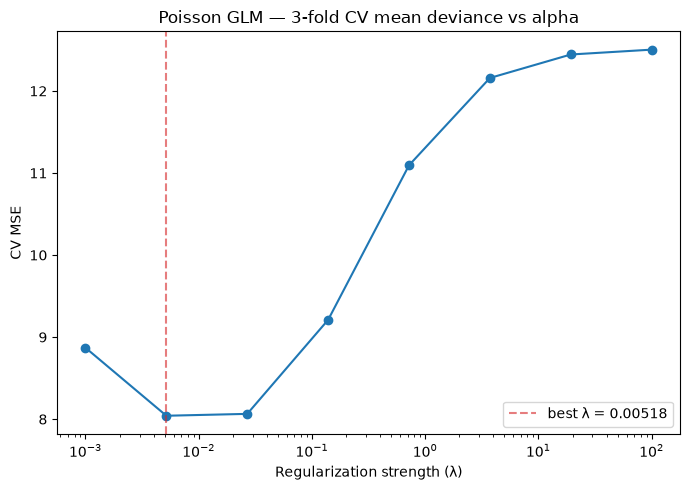

Poisson: alpha=0.005179  lbfgs iters=70  n_obs=68,776


In [3]:
# power=1 -> Poisson deviance (Var proportional to mean); the family the study is about.
F_pois, J_pois, info_pois = R.fit_weights_glm_from_data(seq_matrix, ratio, power=1, seed=0)
print()
fig = plot_cv_curve(info_pois["alphas_grid"], info_pois["cv_deviance"],
                     title="Poisson GLM — 3-fold CV mean deviance vs alpha")
plt.show()
print(f"Poisson: alpha={info_pois['alpha']:.4g}  lbfgs iters={info_pois['n_iter']}  "
      f"n_obs={info_pois['n_obs']:,}")

alphas_grid was not defined thus alphas_grid = [1.00000000e-03 5.17947468e-03 2.68269580e-02 1.38949549e-01
 7.19685673e-01 3.72759372e+00 1.93069773e+01 1.00000000e+02]



GLM CV:   0%|          | 0/3 [00:00<?, ?it/s]


GLM CV:  33%|███▎      | 1/3 [00:11<00:22, 11.30s/it]


GLM CV:  67%|██████▋   | 2/3 [00:24<00:12, 12.52s/it]


GLM CV: 100%|██████████| 3/3 [00:38<00:00, 12.93s/it]

[Gamma] best alpha: 0.02683  (CV on 25,000 rows)


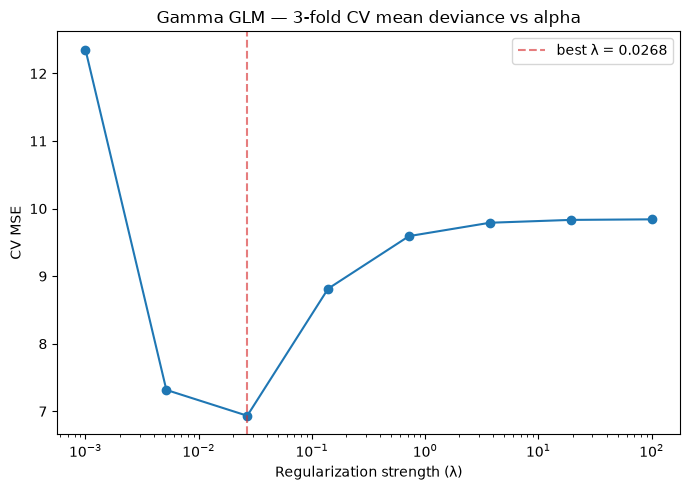

Gamma: alpha=0.02683  lbfgs iters=20


In [4]:
# power=2 -> Gamma (constant coefficient of variation) -- the Tweedie member matched to a
# positive ratio with wide dynamic range; carried as a reference, not the subject of the study.
F_gamma, J_gamma, info_gamma = R.fit_weights_glm_from_data(seq_matrix, ratio, power=2, seed=0)
print()
fig = plot_cv_curve(info_gamma["alphas_grid"], info_gamma["cv_deviance"],
                     title="Gamma GLM — 3-fold CV mean deviance vs alpha")
plt.show()
print(f"Gamma: alpha={info_gamma['alpha']:.4g}  lbfgs iters={info_gamma['n_iter']}")

### 2a. Ridge Potts GT + baseline protocol config

`F_potts`/`J_potts` from `AAV9_potts_regression.ipynb` (joint ridge regression on this exact
`aav9.csv`), loaded via `initialize_weights.py` — the incumbent GT, carried through every
comparison below.

Baseline hyperparameters are the project's established operating point
(`mu=50`, `T_viab=1.3` — the Potts-GT base temperature, cf. `CLAUDE.md` 2026-08-31 —
`noise_viab=0.5`, `D=1e9`), identical to `AAV9_potts_GT_score_study.ipynb` so the
distributions are directly comparable. **Not re-calibrated for the Poisson/Gamma GT** — their
score scale differs from the ridge GT's, so `T_viab` (which divides the score inside
`exp(score/T_viab)`) is only nominal here; the deterministic-score comparisons (sections 3–6)
are unaffected by this, only the protocol simulation (section 7) is.

In [5]:
F_potts = load_F_viab_aav9_potts()
J_potts = load_J_viab_aav9_potts()

RHO_REF, MU_FIXED, T_VIAB_FIXED, NOISE_VIAB_FIXED, D_FIXED = 1e-3, 50, 1.3, 0.5, 1e9
DILUTION_FACTOR, T_SEL_FIXED, eps = 10, 1.0, 1.0
N1_FIXED = MU_FIXED * d0 / RHO_REF
N0_FIXED = N1_FIXED * 150

def make_protocol(F, J, seed=0):
    return ProtocolV3(multinomialNGS=True, key=jax.random.key(seed),
        N0=N0_FIXED, N1=N1_FIXED, rho=RHO_REF,
        dilution_factor=DILUTION_FACTOR, sequences=sequences, D=D_FIXED,
        F_viab=F, J_viab=J, F_sel=jnp.zeros_like(F), J_sel=jnp.zeros_like(J),
        noise_viab=NOISE_VIAB_FIXED, noise_sel=0.0, T_sel=T_SEL_FIXED, T_viab=T_VIAB_FIXED)

protocol_pois  = make_protocol(F_pois,  J_pois)
protocol_potts = make_protocol(F_potts, J_potts)
print(f"mu = {protocol_pois._rho * protocol_pois.N1 / d0:.2f}   N1={N1_FIXED:.3e}   N0={N0_FIXED:.3e}")

mu = 50.00   N1=3.439e+09   N0=5.158e+11


## 3. Direct weight comparison

How correlated are the raw fitted parameters, Poisson (and Gamma) vs the ridge Potts GT?
`F` is `(A, L) = (20, 7)`; `J` is `(L, L, A, A)`, only the `i < j` off-diagonal blocks carry
information.

Poisson   r(F vs F_potts) = +0.9233    r(J vs J_potts, off-diag) = +0.5434
Gamma     r(F vs F_potts) = +0.9452    r(J vs J_potts, off-diag) = +0.5123


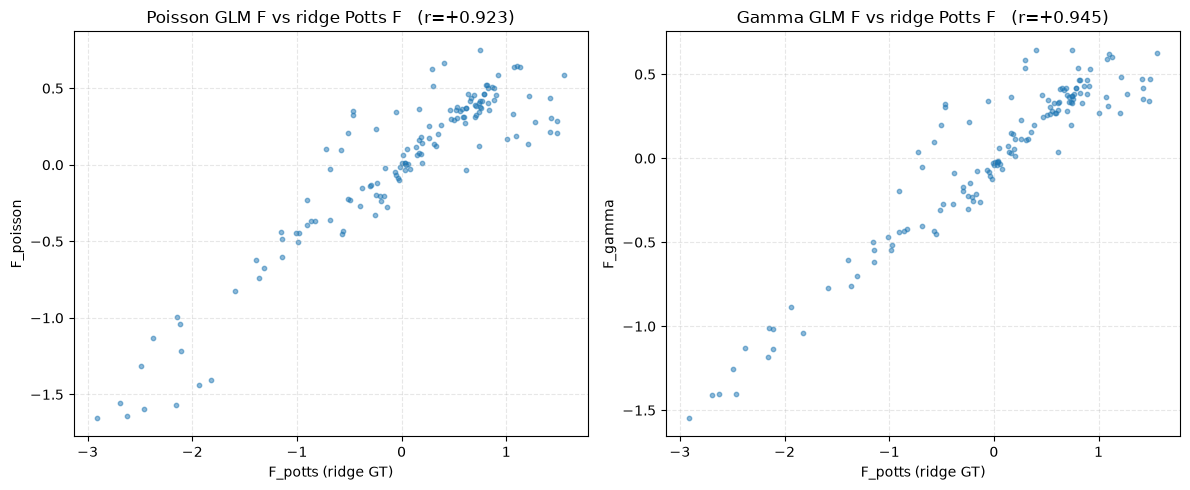

In [6]:
F_potts_np, J_potts_np = np.asarray(F_potts), np.asarray(J_potts)
iu = np.triu_indices(NUM_POSITIONS, k=1)

def weight_corr(name, F, J):
    F, J = np.asarray(F), np.asarray(J)
    rF = pearson(F_potts_np.ravel(), F.ravel())
    rJ = pearson(J_potts_np[iu].ravel(), J[iu].ravel())
    print(f"{name:8s}  r(F vs F_potts) = {rF:+.4f}    r(J vs J_potts, off-diag) = {rJ:+.4f}")
    return rF, rJ

weight_corr("Poisson", F_pois, J_pois)
weight_corr("Gamma",   F_gamma, J_gamma)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (nm, F) in zip(axes, [("Poisson", F_pois), ("Gamma", F_gamma)]):
    ax.scatter(F_potts_np.ravel(), np.asarray(F).ravel(), s=10, alpha=0.5)
    ax.set_xlabel("F_potts (ridge GT)"); ax.set_ylabel(f"F_{nm.lower()}")
    ax.set_title(f"{nm} GLM F vs ridge Potts F   (r={pearson(F_potts_np.ravel(), np.asarray(F).ravel()):+.3f})")
    ax.grid(True, ls="--", alpha=0.3)
fig.tight_layout(); plt.show()

## 4. A few `J_pois` couplings

Coupling-strength heatmap (mean `|J_ij(a,b)|` per position pair), then the raw amino-acid
heatmap for the 3 strongest pairs — same view as `AAV9_potts_GT_score_study.ipynb` section 2a,
so `J_pois` can be eyeballed against the `J_potts` version there.

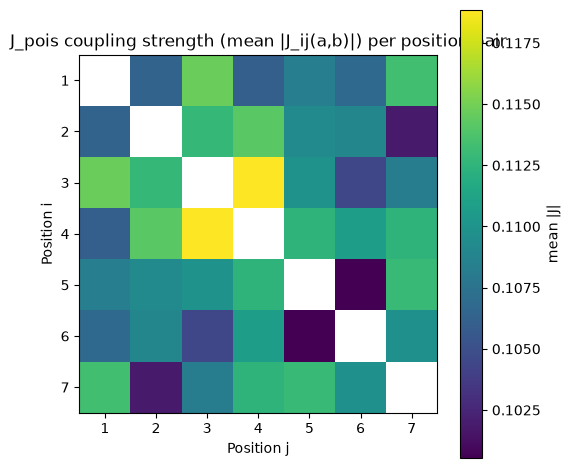

Strongest position pairs by mean |J|: [(3, 4), (1, 3), (2, 4)]


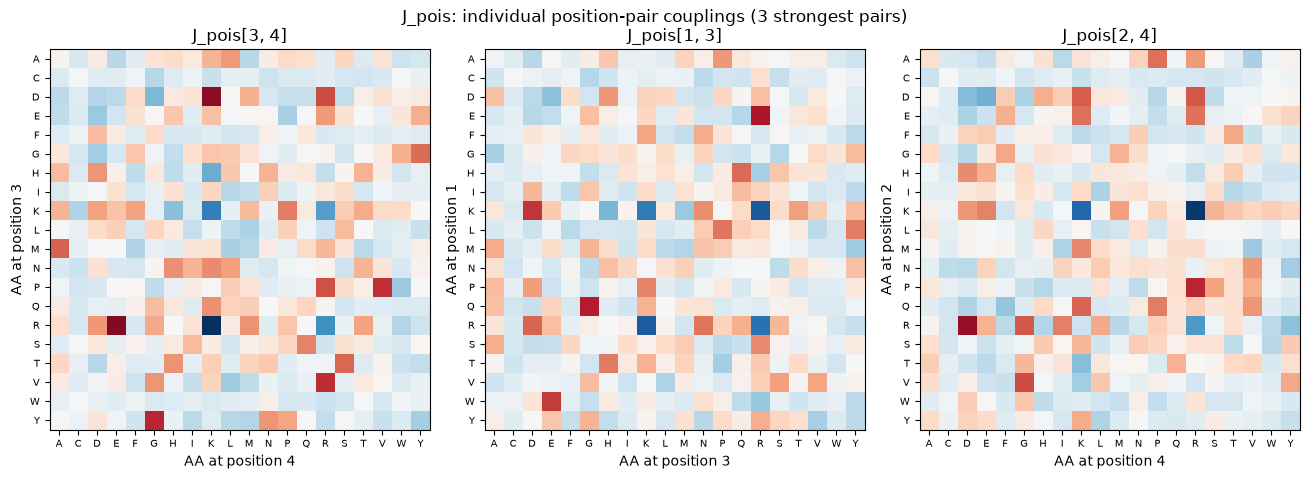

J_pois  off-diagonal: mean|J|=0.1097  max|J|=0.7300
J_potts off-diagonal: mean|J|=0.2474  max|J|=4.1125


In [7]:
J_pois_np = np.asarray(J_pois)
off_diag_L = ~np.eye(NUM_POSITIONS, dtype=bool)

def coupling_strength(J):
    L = J.shape[0]
    od = ~np.eye(L, dtype=bool)
    s = np.full((L, L), np.nan)
    s[od] = np.nanmean(np.abs(J[od]), axis=(1, 2))
    return s

strength = coupling_strength(J_pois_np)
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(strength, cmap="viridis")
ax.set_xlabel("Position j"); ax.set_ylabel("Position i")
ax.set_xticks(range(NUM_POSITIONS)); ax.set_xticklabels(range(1, NUM_POSITIONS + 1))
ax.set_yticks(range(NUM_POSITIONS)); ax.set_yticklabels(range(1, NUM_POSITIONS + 1))
ax.set_title("J_pois coupling strength (mean |J_ij(a,b)|) per position pair")
fig.colorbar(im, ax=ax, label="mean |J|")
fig.tight_layout(); plt.show()

pairs = [(i, j) for i in range(NUM_POSITIONS) for j in range(i + 1, NUM_POSITIONS)]
strongest = sorted(pairs, key=lambda p: -strength[p])[:3]
print("Strongest position pairs by mean |J|:", [(i + 1, j + 1) for i, j in strongest])

vmax = max(np.abs(J_pois_np[i, j]).max() for i, j in strongest)
fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.6))
for ax, (i, j) in zip(axes, strongest):
    im = ax.imshow(J_pois_np[i, j], cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(f"J_pois[{i + 1}, {j + 1}]")
    ax.set_xticks(range(NUM_AMINO_ACIDS)); ax.set_xticklabels(AA_LABELS, fontsize=7)
    ax.set_yticks(range(NUM_AMINO_ACIDS)); ax.set_yticklabels(AA_LABELS, fontsize=7)
    ax.set_xlabel(f"AA at position {j + 1}"); ax.set_ylabel(f"AA at position {i + 1}")
fig.suptitle("J_pois: individual position-pair couplings (3 strongest pairs)")
fig.tight_layout(); plt.show()

print(f"J_pois  off-diagonal: mean|J|={np.mean(np.abs(J_pois_np[off_diag_L])):.4f}  "
      f"max|J|={np.max(np.abs(J_pois_np[off_diag_L])):.4f}")
print(f"J_potts off-diagonal: mean|J|={np.mean(np.abs(J_potts_np[off_diag_L])):.4f}  "
      f"max|J|={np.max(np.abs(J_potts_np[off_diag_L])):.4f}")

## 5. GT score distribution across the real AAV9 library

`compute_score(F, J)` — the deterministic `F + J` score for every real sequence, no protocol
simulation, no noise. Poisson, Gamma and ridge Potts overlaid, each with its Pearson `r`
against the measured `aav9.csv` `target`.

             r_vs_target   mean    std     min    max
GT                                                   
Poisson GLM        0.753  0.155  1.865  -8.062  7.986
Gamma GLM          0.759  0.145  1.630  -7.508  4.394
ridge Potts        0.889  0.354  3.620 -16.161  9.516


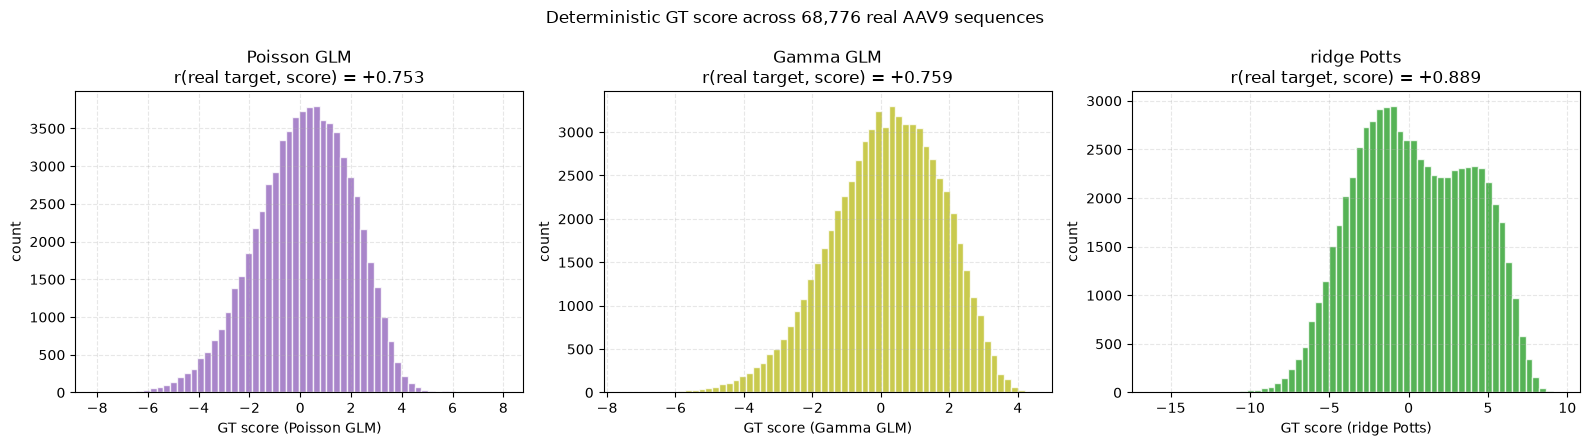

In [8]:
def gt_score(protocol, F, J):
    return np.asarray(protocol.compute_score(F, J))

score_pois  = gt_score(protocol_pois,  F_pois,  J_pois)
score_gamma = gt_score(protocol_pois,  F_gamma, J_gamma)
score_potts = gt_score(protocol_potts, F_potts, J_potts)

rows = []
for nm, sc in [("Poisson GLM", score_pois), ("Gamma GLM", score_gamma), ("ridge Potts", score_potts)]:
    rows.append(dict(GT=nm, r_vs_target=pearson(target, sc),
                     mean=sc.mean(), std=sc.std(), min=sc.min(), max=sc.max()))
gt_df = pd.DataFrame(rows).set_index("GT").round(3)
print(gt_df)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=False)
for ax, (nm, sc, c) in zip(axes, [("Poisson GLM", score_pois, "tab:purple"),
                                   ("Gamma GLM", score_gamma, "tab:olive"),
                                   ("ridge Potts", score_potts, "tab:green")]):
    ax.hist(sc, bins=60, color=c, alpha=0.8, edgecolor="white")
    ax.set_xlabel(f"GT score ({nm})"); ax.set_ylabel("count")
    ax.set_title(f"{nm}\nr(real target, score) = {pearson(target, sc):+.3f}")
    ax.grid(True, ls="--", alpha=0.3)
fig.suptitle(f"Deterministic GT score across {d0:,} real AAV9 sequences")
fig.tight_layout(); plt.show()

## 6. Percentile recovery: does the Poisson GT score rank sequences correctly?

Of the REAL top-k% sequences (ranked by measured `target`), what fraction does each GT score's
own top-k% recover (`analysisV1.precision_at_k`)? Random-guessing baseline at percentile `p`
is `p` itself.

            Poisson GLM  Gamma GLM  ridge Potts  random_baseline
percentile                                                      
1                 0.515      0.143        0.073             0.01
2                 0.481      0.202        0.121             0.02
5                 0.500      0.325        0.260             0.05
10                0.563      0.453        0.449             0.10
20                0.677      0.649        0.703             0.20
30                0.744      0.760        0.853             0.30
50                0.816      0.832        0.909             0.50
70                0.860      0.871        0.900             0.70
100               1.000      1.000        1.000             1.00


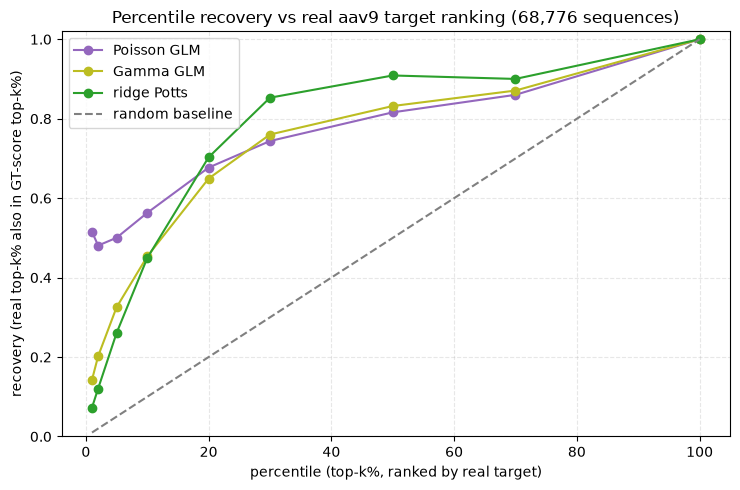

In [9]:
PERCENTILES = [1, 2, 5, 10, 20, 30, 50, 70, 100]
rec = {nm: [] for nm in ["Poisson GLM", "Gamma GLM", "ridge Potts"]}
for pct in PERCENTILES:
    kf = pct / 100
    rec["Poisson GLM"].append(precision_at_k(target, score_pois, k_frac=kf))
    rec["Gamma GLM"].append(precision_at_k(target, score_gamma, k_frac=kf))
    rec["ridge Potts"].append(precision_at_k(target, score_potts, k_frac=kf))

rec_df = pd.DataFrame(rec, index=PERCENTILES); rec_df.index.name = "percentile"
rec_df["random_baseline"] = [p / 100 for p in PERCENTILES]
print(rec_df.round(3))

fig, ax = plt.subplots(figsize=(7.5, 5))
for nm, c in [("Poisson GLM", "tab:purple"), ("Gamma GLM", "tab:olive"), ("ridge Potts", "tab:green")]:
    ax.plot(PERCENTILES, rec_df[nm], marker="o", color=c, label=nm)
ax.plot(PERCENTILES, rec_df["random_baseline"], ls="--", color="gray", label="random baseline")
ax.set_xlabel("percentile (top-k%, ranked by real target)")
ax.set_ylabel("recovery (real top-k% also in GT-score top-k%)")
ax.set_ylim(0, 1.02); ax.legend(); ax.grid(True, ls="--", alpha=0.3)
ax.set_title(f"Percentile recovery vs real aav9 target ranking ({d0:,} sequences)")
fig.tight_layout(); plt.show()

## 7. Protocol-simulated log enrichment using the Poisson GT

One `loop_DE()` round on `protocol_pois` (seeded with `F_pois`/`J_pois`), returning
`target1 = log((lambda2p + eps) / (lambda0p + eps))`, the viability log-enrichment from
simulated NGS reads only — same construction as `AAV9_potts_GT_score_study.ipynb` section 3.
Reminder: `T_viab` is not re-calibrated for this GT (section 2a), so read this as "what the
protocol does to *this* score field", not as a fidelity claim.


PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]


PCR cycles:   2%|▎         | 1/40 [00:01<00:43,  1.12s/it]


PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]


PCR cycles:  90%|█████████ | 36/40 [00:00<00:00, 355.01it/s]


PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]


PCR cycles:  52%|█████▎    | 21/40 [00:00<00:00, 206.26it/s]

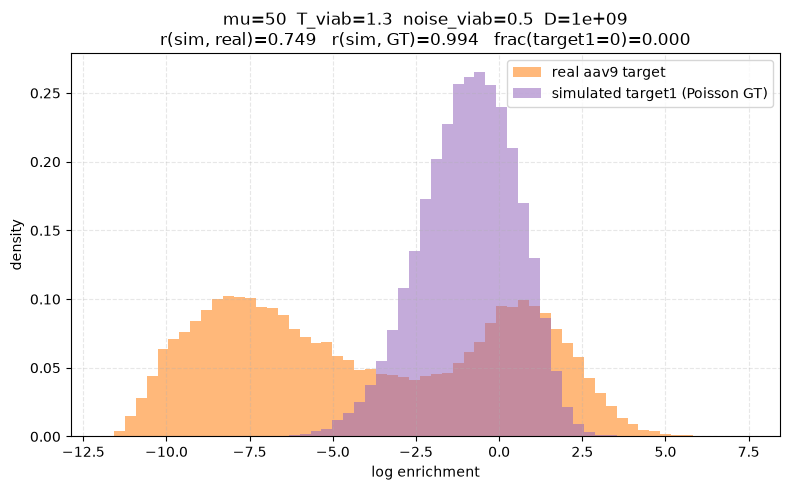

r(simulated target1, real target)  = +0.7487
r(simulated target1, Poisson GT)   = +0.9940
frac(target1 == 0)                 = 0.0000


In [10]:
def viability_target1(protocol, eps=eps):
    protocol.lambda0 = jnp.full(protocol.d0, protocol.N0 / protocol.d0)
    _bio, ngs = protocol.loop_DE()
    lambda0p, lambda2p, _l3 = (np.asarray(a) for a in ngs)
    return np.log((lambda2p + eps) / (lambda0p + eps))

target1_pois = viability_target1(protocol_pois)
r_sim_real = pearson(target1_pois, target)
r_sim_gt   = pearson(target1_pois, score_pois)
frac_zero  = float(np.mean(target1_pois == 0.0))

fig, ax = plt.subplots(figsize=(8, 5))
bins = np.linspace(min(target.min(), target1_pois.min()), max(target.max(), target1_pois.max()), 60)
ax.hist(target,       bins=bins, alpha=0.55, density=True, color="tab:orange", label="real aav9 target")
ax.hist(target1_pois, bins=bins, alpha=0.55, density=True, color="tab:purple", label="simulated target1 (Poisson GT)")
ax.set_xlabel("log enrichment"); ax.set_ylabel("density")
ax.set_title(f"mu={MU_FIXED}  T_viab={T_VIAB_FIXED}  noise_viab={NOISE_VIAB_FIXED}  D={D_FIXED:.0e}\n"
             f"r(sim, real)={r_sim_real:.3f}   r(sim, GT)={r_sim_gt:.3f}   frac(target1=0)={frac_zero:.3f}")
ax.legend(); ax.grid(True, ls="--", alpha=0.3)
fig.tight_layout(); plt.show()

print(f"r(simulated target1, real target)  = {r_sim_real:+.4f}")
print(f"r(simulated target1, Poisson GT)   = {r_sim_gt:+.4f}")
print(f"frac(target1 == 0)                 = {frac_zero:.4f}")

## 8. Overlay: GT score vs simulated log enrichment

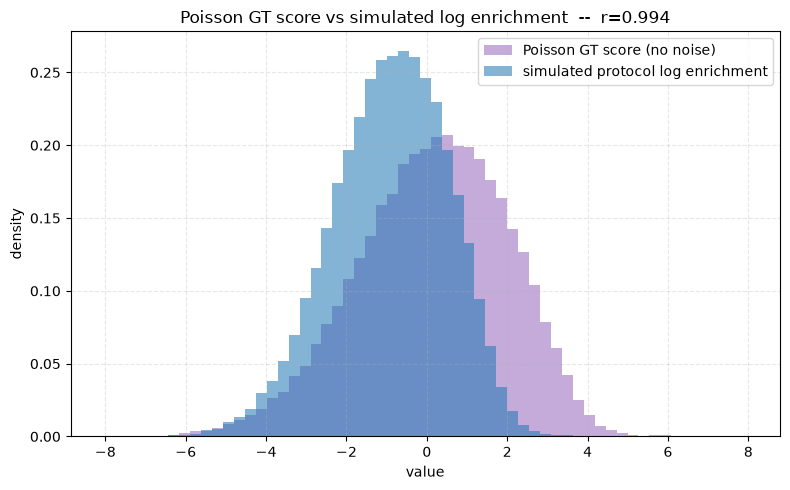

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
bs = np.linspace(min(score_pois.min(), target1_pois.min()), max(score_pois.max(), target1_pois.max()), 60)
ax.hist(score_pois,   bins=bs, alpha=0.55, density=True, color="tab:purple", label="Poisson GT score (no noise)")
ax.hist(target1_pois, bins=bs, alpha=0.55, density=True, color="tab:blue",   label="simulated protocol log enrichment")
ax.set_xlabel("value"); ax.set_ylabel("density")
ax.set_title(f"Poisson GT score vs simulated log enrichment  --  r={r_sim_gt:.3f}")
ax.legend(); ax.grid(True, ls="--", alpha=0.3)
fig.tight_layout(); plt.show()

## 9. Read-out (executed run)

**Aggregate correlation** — `r`(deterministic GT score, real `aav9` target), section 5:

| GT | `r` vs target | best `alpha` | mean&nbsp;\|J\|<sub>off-diag</sub> | max&nbsp;\|J\| |
|---|---|---|---|---|
| Poisson GLM | **0.753** | 5.2e-3 | 0.110 | 0.73 |
| Gamma GLM | **0.759** | 2.7e-2 | ~0.11 | — |
| ridge Potts (incumbent) | **0.889** | 24 | 0.247 | 4.11 |

Both GLMs trail the ridge by ~0.13 on aggregate `r`. `F` still tracks the ridge GT well
(`r(F, F_potts)` = 0.92 Poisson / 0.95 Gamma), but `J` diverges hard (`r(J, J_potts)` ≈ 0.52,
and the GLM couplings are ~2× weaker). The tail-dominated Poisson/Gamma deviance buys much
less epistasis than the ridge MSE does.

**Percentile recovery** (section 6) — the non-obvious part:

| top-k% of real target | Poisson | Gamma | ridge Potts |
|---|---|---|---|
| 1% | **0.52** | 0.14 | 0.07 |
| 5% | **0.50** | 0.33 | 0.26 |
| 10% | **0.56** | 0.45 | 0.45 |
| 20% | 0.68 | 0.65 | **0.70** |
| 30% | 0.74 | 0.76 | **0.85** |
| 50% | 0.82 | 0.83 | **0.91** |

The Poisson GLM **recovers the extreme top (1–10%) markedly better than the ridge Potts GT** —
exactly because its loss concentrates on the most-enriched sequences. The ridge GT retakes the
lead from ~20 % on (better overall rank structure). So "Poisson is worse" holds only for
aggregate `r` / mid-ranking; for *picking out the very best variants* — the project's actual
goal — the tail-weighted Poisson fit is the stronger ranker here.

**Protocol simulation** (section 7): `r`(simulated `target1`, Poisson GT score) = 0.994 (the
protocol carries the GT faithfully), `r`(simulated `target1`, real target) = 0.749,
`frac(target1=0)` = 0.000.

**Take-away**: on `aav9.csv` alone (log enrichment + constant `error`, no counts) the
Gaussian-on-log ridge is the better *general-purpose* GT, but the Poisson GLM is a genuinely
better **top-k ranker** — worth keeping for the downstream "find the best variants" use even
though its aggregate `r` is lower. A count-aware Poisson/NB GT (needs raw plasmid/vector
counts — `aav2.csv`/`aav5.csv` have them, `aav9.csv` doesn't) is the version that could get
both.

### Optional — save the Poisson/Gamma weights

Experimental GTs, saved alongside (not replacing) the ridge Potts GT. No loader added to
`initialize_weights.py`.

In [12]:
import os
for name, F, J in [("poisson", F_pois, J_pois), ("gamma", F_gamma, J_gamma)]:
    fp = os.path.join(_V2_LIB, f"aav9_F_viab_{name}.npy")
    jp = os.path.join(_V2_LIB, f"aav9_J_viab_{name}.npy")
    np.save(fp, np.asarray(F, dtype=np.float32))
    np.save(jp, np.asarray(J, dtype=np.float32))
    print(f"saved {name}: {fp}")

saved poisson: /home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/Modelization_V2/lib/aav9_F_viab_poisson.npy
saved gamma: /home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/Modelization_V2/lib/aav9_F_viab_gamma.npy
